# Imports

In [1]:
from torch.utils.data import DataLoader, random_split
import torch
from data import PermutationDataset
from model import PermutationModel
from train import train_one_epoch, evaluate_model
import matplotlib.pyplot as plt

# Parameters
This includes parameters for what to train on and predict, and also the hyperparameters for training.

In [8]:
n = 6
label_name = "stat2"
layers = [2]

epochs = 1000
train_split, test_split = 0.8, 0.2
learning_rate = 0.001
momentum = 0.9
batch_size = 64

# Initialization
Initialize the data loaders, model, loss function, optimizers.

In [9]:
full_dataset = PermutationDataset(n, label_name)
training_dataset, test_dataset = random_split(full_dataset, [train_split, test_split])
model = PermutationModel(n, layers)
loss_fn = torch.nn.CrossEntropyLoss(full_dataset.class_weights())
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
losses = []

# Training loop
Train the model for the appropriate number of epochs and then save the model in `models`.

In [10]:
for epoch in range(epochs):
    model.train(True)
    current_loss = train_one_epoch(training_loader, model, loss_fn, optimizer)
    print(f"Epoch {epoch}, Loss {current_loss}")
    losses.append(current_loss)

torch.save(model.state_dict(), f"models/{label_name}_{n}.pt")

Epoch 0, Loss 6.501374959945679
Epoch 1, Loss 6.456754744052887
Epoch 2, Loss 6.391224026679993
Epoch 3, Loss 6.324437201023102
Epoch 4, Loss 6.252122640609741
Epoch 5, Loss 6.183883547782898
Epoch 6, Loss 6.118636250495911
Epoch 7, Loss 6.050970375537872
Epoch 8, Loss 5.988018810749054
Epoch 9, Loss 5.925732493400574
Epoch 10, Loss 5.865190207958221
Epoch 11, Loss 5.80550754070282
Epoch 12, Loss 5.749756097793579
Epoch 13, Loss 5.692110300064087
Epoch 14, Loss 5.636932194232941
Epoch 15, Loss 5.583305299282074
Epoch 16, Loss 5.530373156070709
Epoch 17, Loss 5.479018330574036
Epoch 18, Loss 5.427901029586792
Epoch 19, Loss 5.378032088279724
Epoch 20, Loss 5.329315602779388
Epoch 21, Loss 5.281308114528656
Epoch 22, Loss 5.234285831451416
Epoch 23, Loss 5.188227593898773
Epoch 24, Loss 5.142712712287903
Epoch 25, Loss 5.098566651344299
Epoch 26, Loss 5.054892063140869
Epoch 27, Loss 5.011038899421692
Epoch 28, Loss 4.969701170921326
Epoch 29, Loss 4.927874445915222
Epoch 30, Loss 4.8873

# Print the loss curve
Visualize the loss curve to ensure that the model is learning correctly. Save the loss curve in `figures/` so that you can refer to them later.

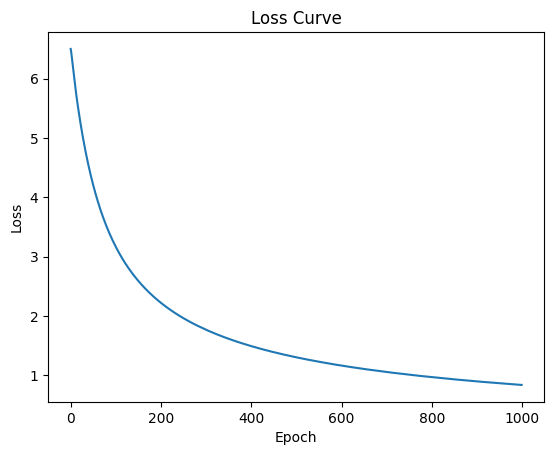

In [11]:
# TODO
# Create a figure and axis
fig, ax = plt.subplots()

# Plot the loss curve
ax.plot(range(len(losses)), losses)

# Add labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve')

# Show the plot
plt.show()

# Evaluate the model
Compute the confusion matrix on the train and test dataset and print out the accuracy and plot the confusion matrix.

In [12]:
# TODO
confusion_matrix = evaluate_model(model, test_dataset)
confusion_matrix.print_accuracy()

Accuracy for class 0 = 100.0%
Accuracy for class 1 = 100.0%
Overall accuracy = 100.0%


# Plot model weights and connections.
Plot the model weights and connections in order to attempt to interpret what the model is learning.

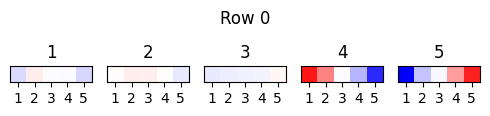

In [7]:
model.plot_heatmap_feature(0,0)